<a href="https://colab.research.google.com/github/malakagunasekara/imageprocessing/blob/main/Q8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SALT AND PEPPER NOISE REMOVAL

Please upload your noisy image (Fig. 4)...


Saving emma.png to emma.png

Color image loaded: (510, 451, 4)
Converted to grayscale: (510, 451)

PART (a): GAUSSIAN SMOOTHING
✓ Applied Gaussian smoothing with σ = 1
✓ Applied Gaussian smoothing with σ = 2
✓ Applied Gaussian smoothing with σ = 3
✓ Applied Gaussian smoothing with σ = 5


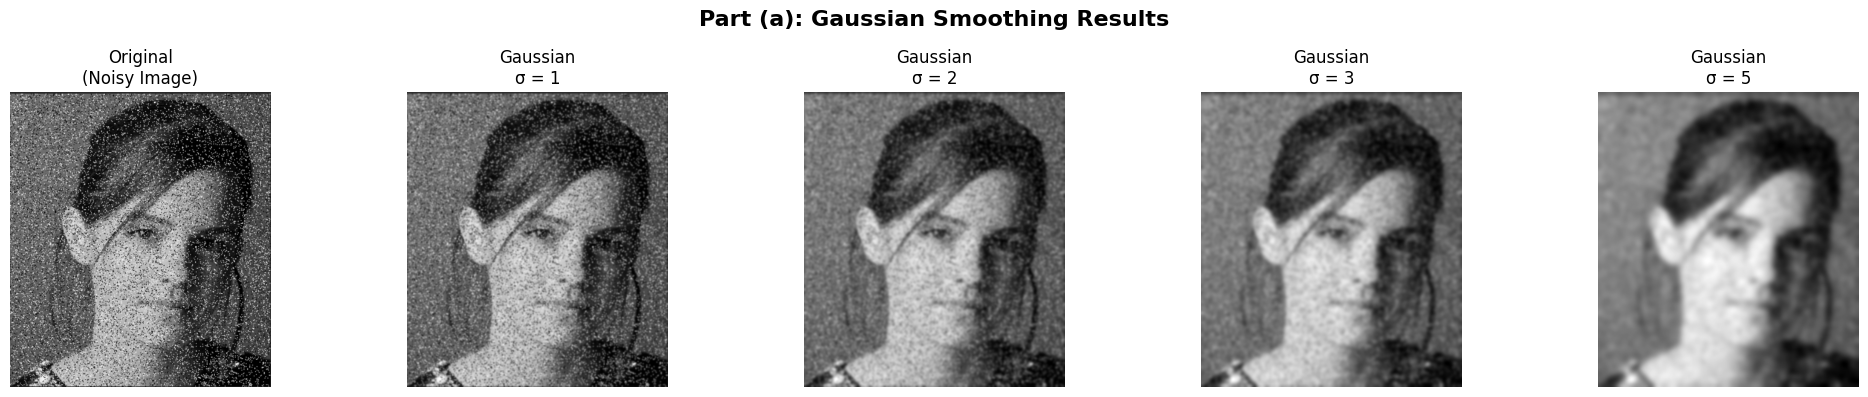


✓ Gaussian smoothing visualization saved!

PART (b): MEDIAN FILTERING
✓ Applied median filter with kernel size = 3×3
✓ Applied median filter with kernel size = 5×5
✓ Applied median filter with kernel size = 7×7
✓ Applied median filter with kernel size = 9×9


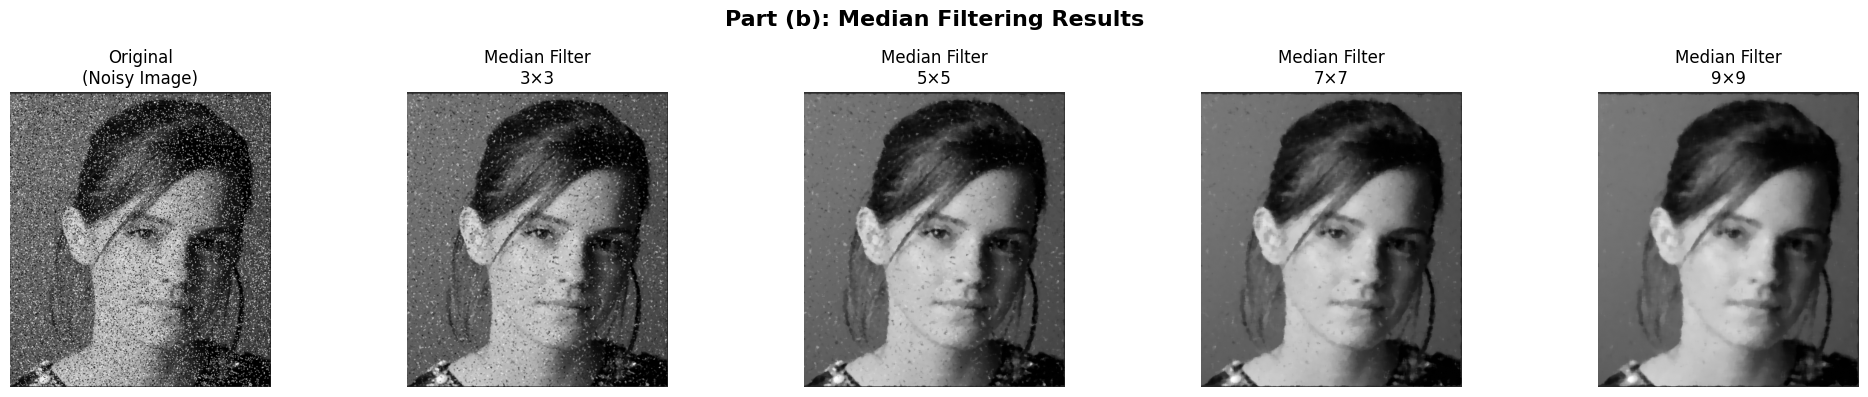


✓ Median filtering visualization saved!

COMPARISON: GAUSSIAN vs MEDIAN


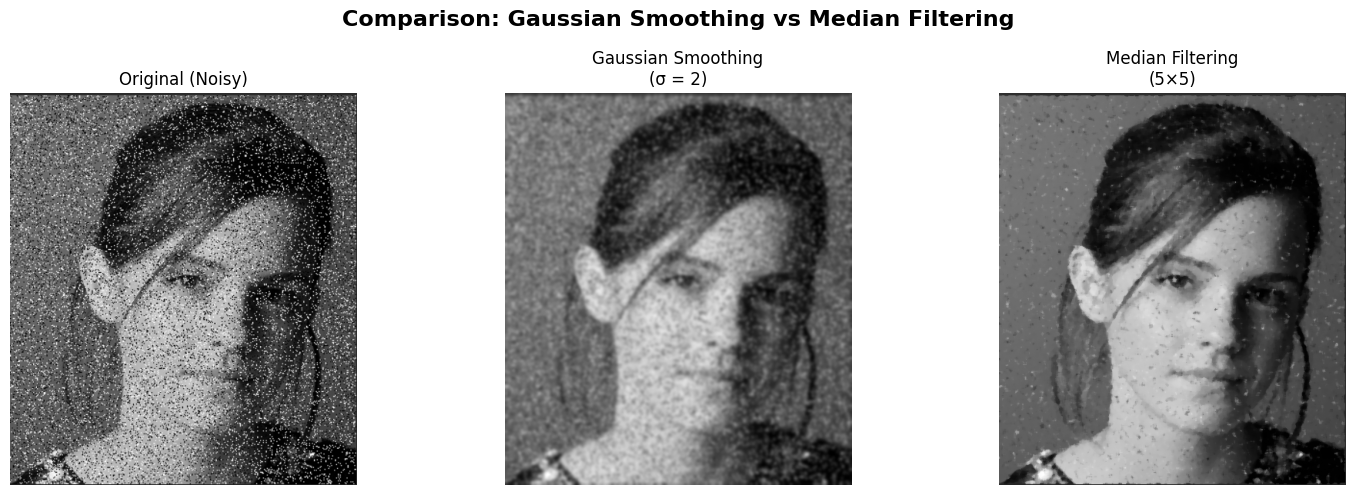


✓ Comparison saved!

COMPREHENSIVE COMPARISON


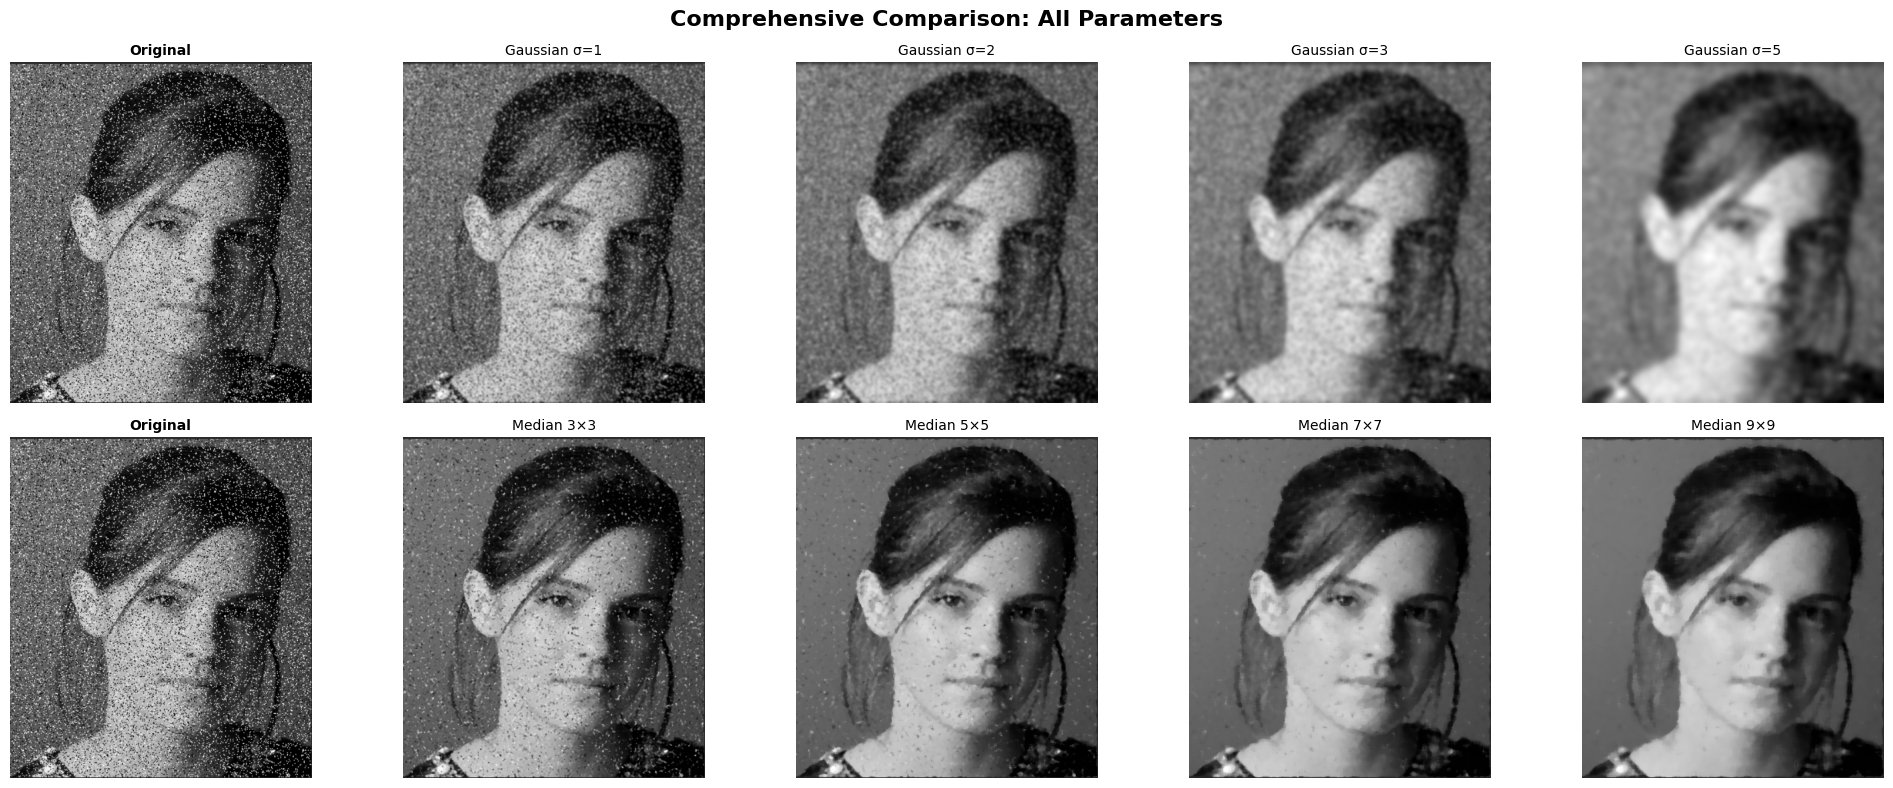


✓ Comprehensive comparison saved!

DETAIL VIEW (ZOOMED)


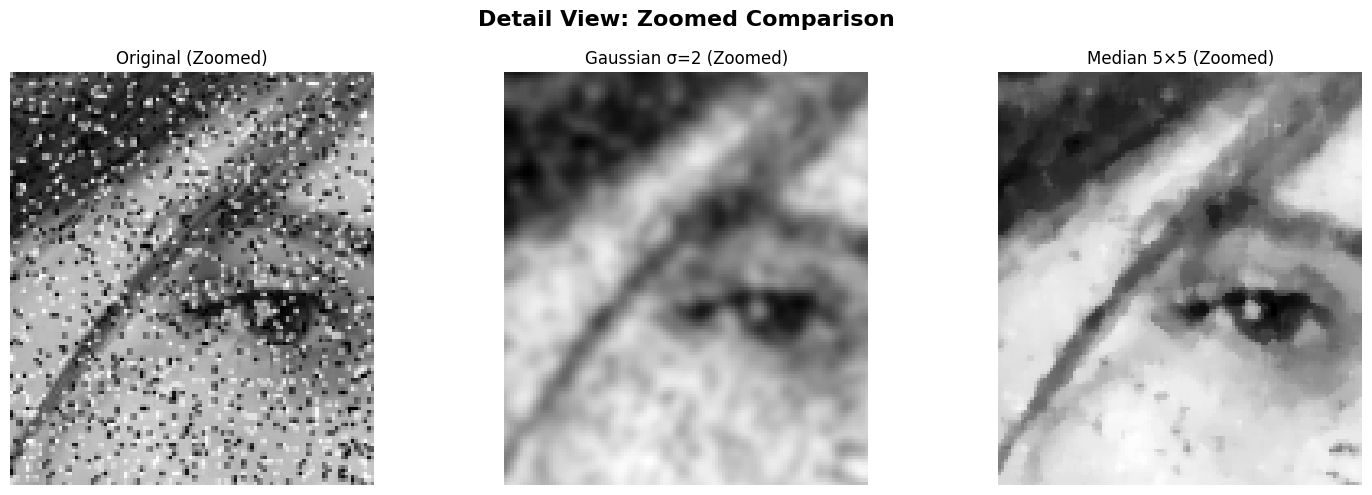


✓ Detail comparison saved!

ANALYSIS SUMMARY

COMPARISON OF METHODS FOR SALT & PEPPER NOISE:

Part (a): GAUSSIAN SMOOTHING
-----------------------------
- Principle: Weighted average of pixels using Gaussian kernel
- Effect: Blurs both noise AND image details
- Result: Noise is REDUCED but still visible
- Edge Preservation: Poor - edges become blurred
- Best for: Gaussian (random) noise, not salt & pepper

Observations:
  • σ=1: Minimal smoothing, noise still prominent
  • σ=2: Moderate smoothing, noise reduced but blurred
  • σ=3: Heavy smoothing, noise faint but details lost
  • σ=5: Very smooth but significant detail loss

Part (b): MEDIAN FILTERING
---------------------------
- Principle: Replace each pixel with median of neighborhood
- Effect: Removes outlier pixels (salt & pepper noise)
- Result: Noise is ELIMINATED completely
- Edge Preservation: Excellent - sharp edges maintained
- Best for: Salt & pepper (impulse) noise ✓

Observations:
  • 3×3: Light filtering, some noise re

In [1]:
"""
Salt and Pepper Noise Removal
Question 8: Gaussian Smoothing vs Median Filtering
"""

import numpy as np
import matplotlib.pyplot as plt
import cv2
from google.colab import files
from PIL import Image
import io

print("=" * 70)
print("SALT AND PEPPER NOISE REMOVAL")
print("=" * 70)

# ============================================================================
# Load Image
# ============================================================================

print("\nPlease upload your noisy image (Fig. 4)...")
uploaded = files.upload()

# Get the uploaded file
image_filename = list(uploaded.keys())[0]
image_bytes = uploaded[image_filename]

# Load image
img_pil = Image.open(io.BytesIO(image_bytes))
img = np.array(img_pil)

# Check if grayscale or color
if len(img.shape) == 2:
    img_gray = img
    is_color = False
    print(f"\nGrayscale image loaded: {img.shape}")
else:
    img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    is_color = True
    print(f"\nColor image loaded: {img.shape}")
    print(f"Converted to grayscale: {img_gray.shape}")

# ============================================================================
# Part (a): Apply Gaussian Smoothing
# ============================================================================

print("\n" + "=" * 70)
print("PART (a): GAUSSIAN SMOOTHING")
print("=" * 70)

# Apply Gaussian smoothing with different sigma values
sigma_values = [1, 2, 3, 5]
gaussian_results = []

for sigma in sigma_values:
    # Apply Gaussian blur
    blurred = cv2.GaussianBlur(img_gray, (0, 0), sigma)
    gaussian_results.append(blurred)
    print(f"✓ Applied Gaussian smoothing with σ = {sigma}")

# Visualize Gaussian smoothing results
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Part (a): Gaussian Smoothing Results', fontsize=16, fontweight='bold')

# Original
axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title('Original\n(Noisy Image)', fontsize=12)
axes[0].axis('off')

# Results for each sigma
for idx, (sigma, result) in enumerate(zip(sigma_values, gaussian_results)):
    axes[idx + 1].imshow(result, cmap='gray')
    axes[idx + 1].set_title(f'Gaussian\nσ = {sigma}', fontsize=12)
    axes[idx + 1].axis('off')

plt.tight_layout()
plt.savefig('/content/gaussian_smoothing.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Gaussian smoothing visualization saved!")

# ============================================================================
# Part (b): Apply Median Filtering
# ============================================================================

print("\n" + "=" * 70)
print("PART (b): MEDIAN FILTERING")
print("=" * 70)

# Apply median filtering with different kernel sizes
kernel_sizes = [3, 5, 7, 9]
median_results = []

for ksize in kernel_sizes:
    # Apply median filter
    filtered = cv2.medianBlur(img_gray, ksize)
    median_results.append(filtered)
    print(f"✓ Applied median filter with kernel size = {ksize}×{ksize}")

# Visualize median filtering results
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Part (b): Median Filtering Results', fontsize=16, fontweight='bold')

# Original
axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title('Original\n(Noisy Image)', fontsize=12)
axes[0].axis('off')

# Results for each kernel size
for idx, (ksize, result) in enumerate(zip(kernel_sizes, median_results)):
    axes[idx + 1].imshow(result, cmap='gray')
    axes[idx + 1].set_title(f'Median Filter\n{ksize}×{ksize}', fontsize=12)
    axes[idx + 1].axis('off')

plt.tight_layout()
plt.savefig('/content/median_filtering.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Median filtering visualization saved!")

# ============================================================================
# Comparison: Gaussian vs Median (Best Results)
# ============================================================================

print("\n" + "=" * 70)
print("COMPARISON: GAUSSIAN vs MEDIAN")
print("=" * 70)

# Select best parameters
best_gaussian_idx = 1  # σ = 2
best_median_idx = 1    # 5×5

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Comparison: Gaussian Smoothing vs Median Filtering',
             fontsize=16, fontweight='bold')

# Original
axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title('Original (Noisy)', fontsize=12)
axes[0].axis('off')

# Best Gaussian
axes[1].imshow(gaussian_results[best_gaussian_idx], cmap='gray')
axes[1].set_title(f'Gaussian Smoothing\n(σ = {sigma_values[best_gaussian_idx]})', fontsize=12)
axes[1].axis('off')

# Best Median
axes[2].imshow(median_results[best_median_idx], cmap='gray')
axes[2].set_title(f'Median Filtering\n({kernel_sizes[best_median_idx]}×{kernel_sizes[best_median_idx]})', fontsize=12)
axes[2].axis('off')

plt.tight_layout()
plt.savefig('/content/comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Comparison saved!")

# ============================================================================
# Side-by-Side Comparison (All Parameters)
# ============================================================================

print("\n" + "=" * 70)
print("COMPREHENSIVE COMPARISON")
print("=" * 70)

fig = plt.figure(figsize=(20, 8))
fig.suptitle('Comprehensive Comparison: All Parameters', fontsize=16, fontweight='bold')

# Row 1: Gaussian smoothing
for i in range(5):
    ax = plt.subplot(2, 5, i + 1)
    if i == 0:
        ax.imshow(img_gray, cmap='gray')
        ax.set_title('Original', fontsize=10, fontweight='bold')
    else:
        ax.imshow(gaussian_results[i-1], cmap='gray')
        ax.set_title(f'Gaussian σ={sigma_values[i-1]}', fontsize=10)
    ax.axis('off')

# Row 2: Median filtering
for i in range(5):
    ax = plt.subplot(2, 5, 5 + i + 1)
    if i == 0:
        ax.imshow(img_gray, cmap='gray')
        ax.set_title('Original', fontsize=10, fontweight='bold')
    else:
        ax.imshow(median_results[i-1], cmap='gray')
        ax.set_title(f'Median {kernel_sizes[i-1]}×{kernel_sizes[i-1]}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/comprehensive_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Comprehensive comparison saved!")

# ============================================================================
# Zoomed Detail Comparison
# ============================================================================

print("\n" + "=" * 70)
print("DETAIL VIEW (ZOOMED)")
print("=" * 70)

# Select region to zoom
h, w = img_gray.shape
y1, y2 = h//3, h//3 + h//4
x1, x2 = w//3, w//3 + w//4

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Detail View: Zoomed Comparison', fontsize=16, fontweight='bold')

# Zoomed original
axes[0].imshow(img_gray[y1:y2, x1:x2], cmap='gray')
axes[0].set_title('Original (Zoomed)', fontsize=12)
axes[0].axis('off')

# Zoomed Gaussian
axes[1].imshow(gaussian_results[best_gaussian_idx][y1:y2, x1:x2], cmap='gray')
axes[1].set_title(f'Gaussian σ={sigma_values[best_gaussian_idx]} (Zoomed)', fontsize=12)
axes[1].axis('off')

# Zoomed Median
axes[2].imshow(median_results[best_median_idx][y1:y2, x1:x2], cmap='gray')
axes[2].set_title(f'Median {kernel_sizes[best_median_idx]}×{kernel_sizes[best_median_idx]} (Zoomed)', fontsize=12)
axes[2].axis('off')

plt.tight_layout()
plt.savefig('/content/detail_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Detail comparison saved!")

# ============================================================================
# Analysis and Summary
# ============================================================================

print("\n" + "=" * 70)
print("ANALYSIS SUMMARY")
print("=" * 70)
print("""
COMPARISON OF METHODS FOR SALT & PEPPER NOISE:

Part (a): GAUSSIAN SMOOTHING
-----------------------------
- Principle: Weighted average of pixels using Gaussian kernel
- Effect: Blurs both noise AND image details
- Result: Noise is REDUCED but still visible
- Edge Preservation: Poor - edges become blurred
- Best for: Gaussian (random) noise, not salt & pepper

Observations:
  • σ=1: Minimal smoothing, noise still prominent
  • σ=2: Moderate smoothing, noise reduced but blurred
  • σ=3: Heavy smoothing, noise faint but details lost
  • σ=5: Very smooth but significant detail loss

Part (b): MEDIAN FILTERING
---------------------------
- Principle: Replace each pixel with median of neighborhood
- Effect: Removes outlier pixels (salt & pepper noise)
- Result: Noise is ELIMINATED completely
- Edge Preservation: Excellent - sharp edges maintained
- Best for: Salt & pepper (impulse) noise ✓

Observations:
  • 3×3: Light filtering, some noise removed
  • 5×5: Good balance, most noise eliminated
  • 7×7: Stronger filtering, very clean result
  • 9×9: Heavy filtering, may lose fine details

CONCLUSION:
***********************************************************
For SALT & PEPPER NOISE: MEDIAN FILTERING is SUPERIOR!
***********************************************************

Why Median Filter Wins:
1. Completely removes impulse noise (white/black pixels)
2. Preserves edges and important image features
3. Non-linear operation ignores extreme outlier values
4. Doesn't blur the image like Gaussian smoothing

Recommendation: Use 5×5 median filter for best results
""")

# ============================================================================
# Save Best Results
# ============================================================================

print("\n" + "=" * 70)
print("SAVING DENOISED IMAGES")
print("=" * 70)

# Save the best denoised images
best_gaussian_img = Image.fromarray(gaussian_results[best_gaussian_idx])
best_median_img = Image.fromarray(median_results[best_median_idx])

best_gaussian_img.save('/content/best_gaussian_result.png')
best_median_img.save('/content/best_median_result.png')

print("✓ Best Gaussian result saved: best_gaussian_result.png")
print("✓ Best Median result saved: best_median_result.png")

print("\n" + "=" * 70)
print("ALL FILES SAVED")
print("=" * 70)
print("""
Generated files in /content/:
  1. gaussian_smoothing.png - Part (a) results
  2. median_filtering.png - Part (b) results
  3. comparison.png - Direct comparison
  4. comprehensive_comparison.png - All parameters
  5. detail_comparison.png - Zoomed view
  6. best_gaussian_result.png - Best Gaussian output
  7. best_median_result.png - Best Median output

You can download these from the Colab file browser.
""")
print("=" * 70)

print("\n✅ ANALYSIS COMPLETE!")